In [10]:
import utils
import numpy as np
import pandas as pd
import os
import importlib
import re
from scipy.stats import gaussian_kde

importlib.reload(utils)

import matplotlib.pyplot as plt
import seaborn as sns # Loads in the theme

pd.set_option('future.no_silent_downcasting', True)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', 20)
#pd.set_option('display.width', 1000)

In [11]:
# Make output folder
output_dir = os.path.join('..','..','plots','behavioural', 'responses')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [12]:
# Preparation
pilot_analysis = True
plot_range = [0, 6]

# Loads the datapath, subject_id's and session numbers based on whether we're analysing the study or pilot data
if pilot_analysis:
    raw_output_path = '/Volumes/project/3025011.02/pilot_data/phd_1_task/experiment_output/behavioural_files_pilot_2'
    unique_subject_ids = [802,803,804,805,806,807,808,809,810,811,813,814,815]
    unique_sessions = [1]
else:
    raw_output_path = '/Volumes/project/3025011.02/raw/'
    unique_subject_ids = [5, 10, 11, 14]
    unique_sessions = [1, 2, 3, 4]

# Load and combine the datasets
combined_results_dataframe_all_sessions = utils.import_functions.main(raw_output_path, unique_subject_ids, unique_sessions, pilot_analysis, binary_output=False)

# Invert objectively_correct score
combined_results_dataframe_all_sessions['objectively_incorrect_boolean'] = 1 - combined_results_dataframe_all_sessions['objectively_correct_boolean']

# RT in milliseconds
combined_results_dataframe_all_sessions['RT_ms'] = combined_results_dataframe_all_sessions['RT_s'] * 1000

# Make response_int column
combined_results_dataframe_all_sessions = combined_results_dataframe_all_sessions.dropna(subset=['response'])
combined_results_dataframe_all_sessions = utils.analysis_functions.replace_strings_with_integers(combined_results_dataframe_all_sessions,{'up': 100, 'down': 0}, 'response', 'response_int')

# Split the dataset so that the 1st session is only included in the 'all_sessions' dataframe
if pilot_analysis:
    combined_results_dataframe = combined_results_dataframe_all_sessions
else:
    combined_results_dataframe = combined_results_dataframe_all_sessions[combined_results_dataframe_all_sessions['session'] != 'session-01']

['/Volumes/project/3025011.02/pilot_data/phd_1_task/experiment_output/behavioural_files_pilot_2/behavioural_output_sub-802_session-01_dummy_2024-09-10_11-06-48.csv', '/Volumes/project/3025011.02/pilot_data/phd_1_task/experiment_output/behavioural_files_pilot_2/behavioural_output_sub-803_session-01_dummy_2024-09-10_13-40-11.csv', '/Volumes/project/3025011.02/pilot_data/phd_1_task/experiment_output/behavioural_files_pilot_2/behavioural_output_sub-804_session-01_dummy_2024-09-10_15-41-26.csv', '/Volumes/project/3025011.02/pilot_data/phd_1_task/experiment_output/behavioural_files_pilot_2/behavioural_output_sub-805_session-01_dummy_2024-09-11_09-08-32.csv', '/Volumes/project/3025011.02/pilot_data/phd_1_task/experiment_output/behavioural_files_pilot_2/behavioural_output_sub-806_session-01_dummy_2024-09-11_11-12-35.csv', '/Volumes/project/3025011.02/pilot_data/phd_1_task/experiment_output/behavioural_files_pilot_2/behavioural_output_sub-807_session-01_dummy_2024-09-11_13-42-58.csv', '/Volumes

## Plot the the average responses over the course of the experiment

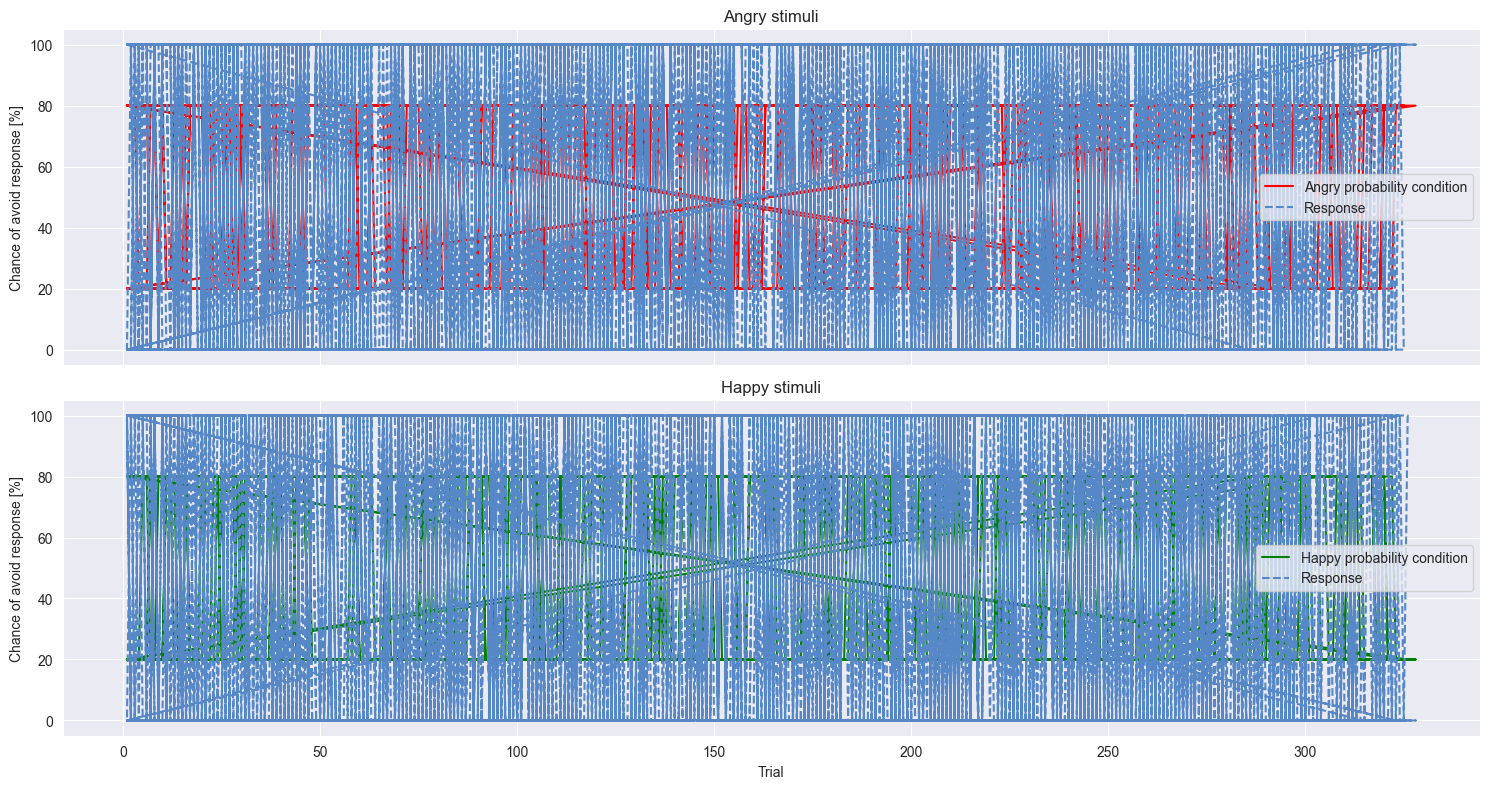

In [13]:
# Jitter vertically to make the lines easier to read when overlapping
dataframe = combined_results_dataframe.dropna(subset=['response'])
dataframe = dataframe.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'])
dataframe['trial_separated'] = (
    dataframe
    .groupby(['subject_id', 'session', 'stimuli_type'])
    .cumcount()
    + 1
)

stimuli_list = ['Angry', 'Happy']
colour_list = ['red', 'green']

stim_types = dataframe['stimuli_type'].unique()
n_types = len(stim_types)

# create one subplot per stimuli_type
fig, axes = plt.subplots(n_types, 1,
                         figsize=(15, 4 * n_types),
                         sharex=True)

# if there's only one type, axes is not a list
if n_types == 1:
    axes = [axes]

for ax, stim in zip(axes, stim_types):
    sub = dataframe[dataframe['stimuli_type'] == stim]
    ax.plot(sub['trial_separated'], sub['probability_condition'], linestyle='-',
            label=f'{stimuli_list[stim-1]} probability condition', color=colour_list[stim-1])
    ax.plot(sub['trial_separated'], sub['response_int'], linestyle='--',
            label='Response', color='#5688C7')
    ax.set_title(f'{stimuli_list[stim-1]} stimuli')
    ax.set_ylabel('Chance of avoid response [%]')
    ax.legend(loc='best')

# common x-axis label
axes[-1].set_xlabel('Trial')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'responses_over_time.pdf'))
plt.show()